In [1]:
!pip install -q diffusers transformers accelerate opencv-python

In [7]:
import os
import torch
import cv2
import json
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers.models import AutoencoderKL, UNet2DConditionModel


# 1. 自定义数据集 (对齐 L0, D1, T1)

class LowLightControlNetDataset(Dataset):
    def __init__(self, exdark_dir, depth_dir, caption_json_path, tokenizer, size=512):
        self.tokenizer = tokenizer
        
        # 1. 加载 JSON
        with open(caption_json_path, 'r', encoding='utf-8') as f:
            raw_captions = json.load(f)
        self.captions_dict = {os.path.splitext(k)[0].lower(): v for k, v in raw_captions.items()}

        # 2. 扫描 Depth 目录
        self.depth_dict = {}
        for root, _, files in os.walk(depth_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    base_name = os.path.splitext(f)[0].lower()
                    self.depth_dict[base_name] = os.path.join(root, f)

        # 3. 扫描 ExDark 目录，进行严格对齐和过滤
        self.valid_data = []
        for root, _, files in os.walk(exdark_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, f)
                    parent_folder = os.path.basename(root)

                    # 只放行 Motorbike 类别
                    if parent_folder.lower() != "motorbike":
                        continue

                    # 修复命名
                    if f.lower().startswith(parent_folder.lower()):
                        normalized_f = f
                    else:
                        normalized_f = f"{parent_folder}_{f}"
                        
                    base_name = os.path.splitext(normalized_f)[0].lower()

                    # 检查深度图是否存在
                    if base_name in self.depth_dict:
                        self.valid_data.append({
                            "img_path": img_path,
                            "depth_path": self.depth_dict[base_name],
                            "base_key": base_name 
                        })

        print(f"🔥 数据过滤完毕！当前仅使用 Motorbike，共成功匹配到 {len(self.valid_data)} 个完整的数据对。")
        if len(self.valid_data) == 0:
            raise ValueError("严重警告：没有找到 Motorbike 的数据，请检查路径或拼写！")

        # 图像与深度图的预处理
        self.image_transforms = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        
        self.condition_transforms = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        item = self.valid_data[idx]
        
        # --- 加载 L0 ---
        image = Image.open(item["img_path"]).convert("RGB")
        image_tensor = self.image_transforms(image)
        
        # --- 加载 D1 ---
        depth_map = Image.open(item["depth_path"]).convert("RGB")
        depth_tensor = self.condition_transforms(depth_map)
        
        # --- 加载 T1 ---
        text = self.captions_dict.get(item["base_key"], "A picture in the dark")
            
        inputs = self.tokenizer(
            text, 
            max_length=self.tokenizer.model_max_length, 
            padding="max_length", 
            truncation=True, 
            return_tensors="pt"
        )
        
        return {
            "pixel_values": image_tensor,     
            "conditioning_pixel_values": depth_tensor, 
            "input_ids": inputs.input_ids.squeeze()    
        }



# 2. 模型初始化与冻结设置
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "runwayml/stable-diffusion-v1-5" # 论文使用的基础模型

# 加载各个组件
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to(device)
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# 初始化 ControlNet
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth").to(device)

# 核心设定：冻结 VAE, U-Net 和 Text Encoder，仅训练 ControlNet
vae.requires_grad_(False)
unet.requires_grad_(False)
text_encoder.requires_grad_(False)
controlnet.train()

# 开启梯度检查点以节省显存
controlnet.enable_gradient_checkpointing()


# 3. 训练超参数与数据加载
batch_size = 2 # 如果提示 CUDA OOM，请将此数值改为 1
learning_rate = 1e-5
num_epochs = 10


EXDARK_DIR = "/kaggle/input/datasets/yapeng111/exdark-dataset" 
DEPTH_DIR = "/kaggle/input/datasets/yapeng111/depth-e-dataset"
CAPTION_DIR = "/kaggle/input/datasets/yapeng111/captions-e/captions_E.json"

dataset = LowLightControlNetDataset(EXDARK_DIR, DEPTH_DIR, CAPTION_DIR, tokenizer)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimizer = torch.optim.AdamW(controlnet.parameters(), lr=learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer, num_warmup_steps=500, num_training_steps=len(dataloader) * num_epochs
)

# 混合精度 Scaler
scaler = torch.cuda.amp.GradScaler()


# 4. 训练循环 (Stage 2: Training Model M1)
print("Starting training...")
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step, batch in enumerate(dataloader):
        # 1. 准备数据
        latents = vae.encode(batch["pixel_values"].to(device, dtype=torch.float32)).latent_dist.sample()
        latents = latents * vae.config.scaling_factor
        
        controlnet_image = batch["conditioning_pixel_values"].to(device, dtype=torch.float32)
        encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]
        
        # 2. 为 Latents 添加噪声 (Forward Diffusion)
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        with torch.cuda.amp.autocast():
            # 3. ControlNet 前向传播
            down_block_res_samples, mid_block_res_sample = controlnet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                controlnet_cond=controlnet_image,
                return_dict=False,
            )
            
            # 4. U-Net 预测噪声 (结合 ControlNet 的输出)
            model_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                down_block_additional_residuals=down_block_res_samples,
                mid_block_additional_residual=mid_block_res_sample,
            ).sample
            
            # 5. 计算 Loss (预测的噪声 vs 实际加入的噪声)
            loss = torch.nn.functional.mse_loss(model_pred.float(), noise.float(), reduction="mean")
        
        # 6. 反向传播与优化
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()
        
        epoch_loss += loss.item()
        
        if step % 50 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Step [{step}/{len(dataloader)}], Loss: {loss.item():.4f}")
            
    print(f"--- Epoch {epoch} Average Loss: {epoch_loss/len(dataloader):.4f} ---")


# 5. 保存训练好的 ControlNet 模型
output_dir = "/kaggle/working/lowlight_controlnet_v1"
controlnet.save_pretrained(output_dir)
print(f"Training complete! Model saved to {output_dir}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔥 数据过滤完毕！当前仅使用 Motorbike，共成功匹配到 503 个完整的数据对。
Starting training...


/tmp/ipykernel_55/343494910.py:154: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/343494910.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [0/10], Step [0/252], Loss: 0.1066
Epoch [0/10], Step [50/252], Loss: 0.1952
Epoch [0/10], Step [100/252], Loss: 0.1073
Epoch [0/10], Step [150/252], Loss: 0.0420
Epoch [0/10], Step [200/252], Loss: 0.0393
Epoch [0/10], Step [250/252], Loss: 0.0723
--- Epoch 0 Average Loss: 0.1508 ---
Epoch [1/10], Step [0/252], Loss: 0.1320
Epoch [1/10], Step [50/252], Loss: 0.1338
Epoch [1/10], Step [100/252], Loss: 0.0152
Epoch [1/10], Step [150/252], Loss: 0.2330
Epoch [1/10], Step [200/252], Loss: 0.0755
Epoch [1/10], Step [250/252], Loss: 0.1288
--- Epoch 1 Average Loss: 0.1564 ---
Epoch [2/10], Step [0/252], Loss: 0.0961
Epoch [2/10], Step [50/252], Loss: 0.0103
Epoch [2/10], Step [100/252], Loss: 0.3297
Epoch [2/10], Step [150/252], Loss: 0.0217
Epoch [2/10], Step [200/252], Loss: 0.0935
Epoch [2/10], Step [250/252], Loss: 0.3167
--- Epoch 2 Average Loss: 0.1485 ---
Epoch [3/10], Step [0/252], Loss: 0.0890
Epoch [3/10], Step [50/252], Loss: 0.5060
Epoch [3/10], Step [100/252], Loss: 0.121

In [1]:
!ls -lh /kaggle/working/lowlight_controlnet_v1

ls: cannot access '/kaggle/working/lowlight_controlnet_v1': No such file or directory


# 20张数据集测试⬇️

In [2]:
import os
import torch
import cv2
import json
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers.models import AutoencoderKL, UNet2DConditionModel

# ==========================================
# 1. 自定义数据集 (精准锁定 20 张 Bicycle)
# ==========================================
class LowLightControlNetDataset(Dataset):
    def __init__(self, exdark_dir, depth_dir, caption_json_path, tokenizer, size=512):
        self.tokenizer = tokenizer
        
        # 1. 加载 JSON
        with open(caption_json_path, 'r', encoding='utf-8') as f:
            raw_captions = json.load(f)
        self.captions_dict = {os.path.splitext(k)[0].lower(): v for k, v in raw_captions.items()}

        # 2. 扫描 Depth 目录
        self.depth_dict = {}
        for root, _, files in os.walk(depth_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    base_name = os.path.splitext(f)[0].lower()
                    self.depth_dict[base_name] = os.path.join(root, f)

        # 🔥 核心修改 1：生成这 20 张图片的“白名单”
        # 会生成 bicycle_2015_00001 到 bicycle_2015_00020 这样的标准名称
        allowed_bases = [f"bicycle_2015_{str(i).zfill(5)}" for i in range(1, 21)]

        # 3. 扫描 ExDark 目录，进行严格对齐和过滤
        self.valid_data = []
        for root, _, files in os.walk(exdark_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, f)
                    parent_folder = os.path.basename(root)

                    # 只放行 Bicycle 类别
                    if parent_folder.lower() != "bicycle":
                        continue

                    # 修复命名
                    if f.lower().startswith(parent_folder.lower()):
                        normalized_f = f
                    else:
                        normalized_f = f"{parent_folder}_{f}"
                        
                    base_name = os.path.splitext(normalized_f)[0].lower()

                    # 🔥 核心修改 2：如果这张图不在白名单的 20 张里，直接跳过
                    if base_name not in allowed_bases:
                        continue

                    # 检查深度图是否存在
                    if base_name in self.depth_dict:
                        self.valid_data.append({
                            "img_path": img_path,
                            "depth_path": self.depth_dict[base_name],
                            "base_key": base_name 
                        })

        print(f"🔥 数据过滤完毕！精准锁定目标，共成功匹配到 {len(self.valid_data)} 个完整的数据对。")
        if len(self.valid_data) == 0:
            raise ValueError("严重警告：没有找到这 20 张 Bicycle 数据，请检查路径！")

        # 图像与深度图的预处理
        self.image_transforms = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        
        self.condition_transforms = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        item = self.valid_data[idx]
        
        # --- 加载 L0 ---
        image = Image.open(item["img_path"]).convert("RGB")
        image_tensor = self.image_transforms(image)
        
        # --- 加载 D1 ---
        depth_map = Image.open(item["depth_path"]).convert("RGB")
        depth_tensor = self.condition_transforms(depth_map)
        
        # --- 加载 T1 ---
        text = self.captions_dict.get(item["base_key"], "A picture in the dark")
            
        inputs = self.tokenizer(
            text, 
            max_length=self.tokenizer.model_max_length, 
            padding="max_length", 
            truncation=True, 
            return_tensors="pt"
        )
        
        return {
            "pixel_values": image_tensor,     
            "conditioning_pixel_values": depth_tensor, 
            "input_ids": inputs.input_ids.squeeze()    
        }

# ==========================================
# 2. 模型初始化与冻结设置
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "runwayml/stable-diffusion-v1-5" 

tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to(device)
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth").to(device)

vae.requires_grad_(False)
unet.requires_grad_(False)
text_encoder.requires_grad_(False)
controlnet.train()

controlnet.enable_gradient_checkpointing()

# ==========================================
# 3. 训练超参数与数据加载
# ==========================================
batch_size = 2 
learning_rate = 1e-5
num_epochs = 10

EXDARK_DIR = "/kaggle/input/datasets/yapeng111/exdark-dataset" 
DEPTH_DIR = "/kaggle/input/datasets/yapeng111/depth-e-dataset"
CAPTION_DIR = "/kaggle/input/datasets/yapeng111/captions-e/captions_E.json"

dataset = LowLightControlNetDataset(EXDARK_DIR, DEPTH_DIR, CAPTION_DIR, tokenizer)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimizer = torch.optim.AdamW(controlnet.parameters(), lr=learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer, num_warmup_steps=10, num_training_steps=len(dataloader) * num_epochs
)

scaler = torch.cuda.amp.GradScaler()

# ==========================================
# 4. 训练循环 (Stage 2: Training Model M1)
# ==========================================
print("🚀 开始极速训练...")
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step, batch in enumerate(dataloader):
        latents = vae.encode(batch["pixel_values"].to(device, dtype=torch.float32)).latent_dist.sample()
        latents = latents * vae.config.scaling_factor
        
        controlnet_image = batch["conditioning_pixel_values"].to(device, dtype=torch.float32)
        encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]
        
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        with torch.cuda.amp.autocast():
            down_block_res_samples, mid_block_res_sample = controlnet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                controlnet_cond=controlnet_image,
                return_dict=False,
            )
            
            model_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                down_block_additional_residuals=down_block_res_samples,
                mid_block_additional_residual=mid_block_res_sample,
            ).sample
            
            loss = torch.nn.functional.mse_loss(model_pred.float(), noise.float(), reduction="mean")
        
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()
        
        epoch_loss += loss.item()
        
        # 因为数据很少，每 5 步打印一次
        if step % 5 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Step [{step}/{len(dataloader)}], Loss: {loss.item():.4f}")
            
    print(f"--- Epoch {epoch} Average Loss: {epoch_loss/len(dataloader):.4f} ---")

# =========================================
# 5. 终极双重保险保存法
# =========================================
print("正在执行双重保存，请勿关闭页面...")

# 保险 1: 官方推荐保存路径
output_dir = "/kaggle/working/lowlight_controlnet_bicycle_20"
controlnet.save_pretrained(output_dir)

# 保险 2: 底层 PyTorch 暴力保存为单个 .pth 文件 (绝对跑不掉)
backup_path = "/kaggle/working/controlnet_bicycle_20_backup.pth"
torch.save(controlnet.state_dict(), backup_path)

print(f"🎉 训练完成！双重保存已落实：\n1. 文件夹: {output_dir}\n2. 权重文件: {backup_path}")

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

🔥 数据过滤完毕！精准锁定目标，共成功匹配到 20 个完整的数据对。
🚀 开始极速训练...


/tmp/ipykernel_55/4044965594.py:157: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/4044965594.py:178: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [0/10], Step [0/10], Loss: 0.1977
Epoch [0/10], Step [5/10], Loss: 0.0845
--- Epoch 0 Average Loss: 0.1627 ---
Epoch [1/10], Step [0/10], Loss: 0.2819
Epoch [1/10], Step [5/10], Loss: 0.3340
--- Epoch 1 Average Loss: 0.2070 ---
Epoch [2/10], Step [0/10], Loss: 0.0073
Epoch [2/10], Step [5/10], Loss: 0.0908
--- Epoch 2 Average Loss: 0.0847 ---
Epoch [3/10], Step [0/10], Loss: 0.2189
Epoch [3/10], Step [5/10], Loss: 0.1617
--- Epoch 3 Average Loss: 0.1356 ---
Epoch [4/10], Step [0/10], Loss: 0.2139
Epoch [4/10], Step [5/10], Loss: 0.1653
--- Epoch 4 Average Loss: 0.1689 ---
Epoch [5/10], Step [0/10], Loss: 0.0611
Epoch [5/10], Step [5/10], Loss: 0.1098
--- Epoch 5 Average Loss: 0.1300 ---
Epoch [6/10], Step [0/10], Loss: 0.2915
Epoch [6/10], Step [5/10], Loss: 0.0127
--- Epoch 6 Average Loss: 0.1346 ---
Epoch [7/10], Step [0/10], Loss: 0.1153
Epoch [7/10], Step [5/10], Loss: 0.2257
--- Epoch 7 Average Loss: 0.1570 ---
Epoch [8/10], Step [0/10], Loss: 0.2249
Epoch [8/10], Step [5/10

🚀 正在加载你炼制的 Bicycle ControlNet...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 成功读取测试深度图: Bicycle_2015_00001.png
✨ 开始生成低光照图像 (20 steps)...


  0%|          | 0/20 [00:00<?, ?it/s]

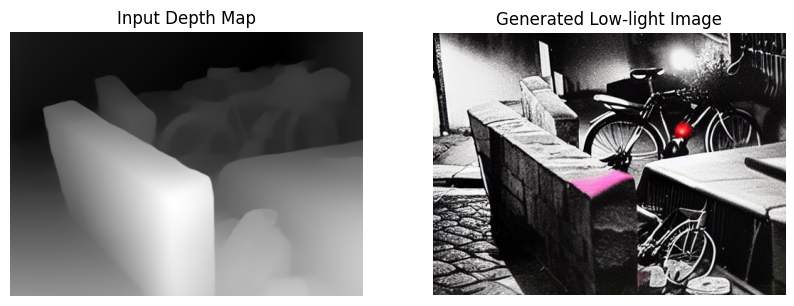

🎉 生成完毕！请查看上方的对比图！


In [3]:
import torch
import os
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
from PIL import Image
import matplotlib.pyplot as plt

print("🚀 正在加载你炼制的 Bicycle ControlNet...")
device = "cuda"
base_model_id = "runwayml/stable-diffusion-v1-5"
# 指向我们刚刚保存的标准文件夹
controlnet_path = "/kaggle/working/lowlight_controlnet_bicycle_20"

# 1. 加载模型
controlnet = ControlNetModel.from_pretrained(controlnet_path, torch_dtype=torch.float16).to(device)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    base_model_id, controlnet=controlnet, torch_dtype=torch.float16
).to(device)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()

# 2. 读取一张你截图里的自行车深度图作为输入
# 选取你列表里的第一张: Bicycle_2015_00001.png
depth_dir = "/kaggle/input/datasets/yapeng111/depth-e-dataset"
test_depth_path = os.path.join(depth_dir, "Bicycle_2015_00001.png")

if not os.path.exists(test_depth_path):
    print(f"⚠️ 找不到测试图片: {test_depth_path}")
else:
    print(f"✅ 成功读取测试深度图: Bicycle_2015_00001.png")
    depth_image = Image.open(test_depth_path).convert("RGB")
    
    # 3. 设置 Prompt (提示词)
    # 根据你 JSON 里的风格，写一个匹配的描述
    prompt = "A picture of a city street at night with bicycles and cars, dark, low light"
    negative_prompt = "bright, sunny, daytime, overexposed, ugly, blurry, high key"

    print("✨ 开始生成低光照图像 (20 steps)...")
    # 4. 生成图像 (参考论文，guidance_scale 设为 5)
    generator = torch.manual_seed(42) # 固定种子
    output_image = pipe(
        prompt,
        image=depth_image,
        negative_prompt=negative_prompt,
        num_inference_steps=20,
        guidance_scale=5.0,
        generator=generator
    ).images[0]

    # 5. 可视化对比
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(depth_image)
    axes[0].set_title("Input Depth Map")
    axes[0].axis("off")
    
    axes[1].imshow(output_image)
    axes[1].set_title("Generated Low-light Image")
    axes[1].axis("off")
    plt.show()

    # 保存生成的图片到工作区
    output_image.save("/kaggle/working/test_generated_bicycle.png")
    print("🎉 生成完毕！请查看上方的对比图！")

In [4]:
!zip -r my_controlnet_backup.zip /kaggle/working/

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/test_generated_bicycle.png (deflated 0%)
  adding: kaggle/working/lowlight_controlnet_bicycle_20/ (stored 0%)
  adding: kaggle/working/lowlight_controlnet_bicycle_20/diffusion_pytorch_model.safetensors (deflated 7%)
  adding: kaggle/working/lowlight_controlnet_bicycle_20/config.json (deflated 60%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 81%)
  adding: kaggle/working/controlnet_bicycle_20_backup.pth (deflated 7%)


# bike数据集测试⬇️

In [1]:
import os
import torch
import cv2
import json
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers.models import AutoencoderKL, UNet2DConditionModel


# 1. 自定义数据集 (完整的 Bicycle 类别 - 652张)
class LowLightControlNetDataset(Dataset):
    def __init__(self, exdark_dir, depth_dir, caption_json_path, tokenizer, size=512):
        self.tokenizer = tokenizer
        
        # 1. 加载 JSON
        with open(caption_json_path, 'r', encoding='utf-8') as f:
            raw_captions = json.load(f)
        self.captions_dict = {os.path.splitext(k)[0].lower(): v for k, v in raw_captions.items()}

        # 2. 扫描 Depth 目录
        self.depth_dict = {}
        for root, _, files in os.walk(depth_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    base_name = os.path.splitext(f)[0].lower()
                    self.depth_dict[base_name] = os.path.join(root, f)

        # 3. 扫描 ExDark 目录，进行严格对齐和过滤
        self.valid_data = []
        for root, _, files in os.walk(exdark_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, f)
                    parent_folder = os.path.basename(root)

                    # 只放行 Bicycle 类别
                    if parent_folder.lower() != "bicycle":
                        continue

                    # 修复命名
                    if f.lower().startswith(parent_folder.lower()):
                        normalized_f = f
                    else:
                        normalized_f = f"{parent_folder}_{f}"
                        
                    base_name = os.path.splitext(normalized_f)[0].lower()

                    # 检查深度图是否存在
                    if base_name in self.depth_dict:
                        self.valid_data.append({
                            "img_path": img_path,
                            "depth_path": self.depth_dict[base_name],
                            "base_key": base_name 
                        })

        print(f"数据过滤完毕！当前使用完整的 Bicycle 类别，共成功匹配到 {len(self.valid_data)} 个完整的数据对。")
        if len(self.valid_data) == 0:
            raise ValueError("Warning：没有找到 Bicycle 数据，请检查路径！")

        # 图像与深度图的预处理
        self.image_transforms = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        
        self.condition_transforms = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        item = self.valid_data[idx]
        
        # --- 加载 L0 ---
        image = Image.open(item["img_path"]).convert("RGB")
        image_tensor = self.image_transforms(image)
        
        # --- 加载 D1 ---
        depth_map = Image.open(item["depth_path"]).convert("RGB")
        depth_tensor = self.condition_transforms(depth_map)
        
        # --- 加载 T1 ---
        text = self.captions_dict.get(item["base_key"], "A picture in the dark")
            
        inputs = self.tokenizer(
            text, 
            max_length=self.tokenizer.model_max_length, 
            padding="max_length", 
            truncation=True, 
            return_tensors="pt"
        )
        
        return {
            "pixel_values": image_tensor,     
            "conditioning_pixel_values": depth_tensor, 
            "input_ids": inputs.input_ids.squeeze()    
        }


# 2. 模型初始化与冻结设置
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "runwayml/stable-diffusion-v1-5" 

tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to(device)
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth").to(device)

vae.requires_grad_(False)
unet.requires_grad_(False)
text_encoder.requires_grad_(False)
controlnet.train()

controlnet.enable_gradient_checkpointing()


# 3. 训练超参数与数据加载
batch_size = 2 
learning_rate = 1e-5
num_epochs = 10

EXDARK_DIR = "/kaggle/input/datasets/yapeng111/exdark-dataset" 
DEPTH_DIR = "/kaggle/input/datasets/yapeng111/depth-e-dataset"
CAPTION_DIR = "/kaggle/input/datasets/yapeng111/captions-e/captions_E.json"

dataset = LowLightControlNetDataset(EXDARK_DIR, DEPTH_DIR, CAPTION_DIR, tokenizer)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimizer = torch.optim.AdamW(controlnet.parameters(), lr=learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer, num_warmup_steps=150, num_training_steps=len(dataloader) * num_epochs
)

scaler = torch.cuda.amp.GradScaler()


# 4. 训练循环 (Stage 2: Training Model M1)
print("开始全量 Bicycle 极速训练...")
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step, batch in enumerate(dataloader):
        latents = vae.encode(batch["pixel_values"].to(device, dtype=torch.float32)).latent_dist.sample()
        latents = latents * vae.config.scaling_factor
        
        controlnet_image = batch["conditioning_pixel_values"].to(device, dtype=torch.float32)
        encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]
        
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        with torch.cuda.amp.autocast():
            down_block_res_samples, mid_block_res_sample = controlnet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                controlnet_cond=controlnet_image,
                return_dict=False,
            )
            
            model_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                down_block_additional_residuals=down_block_res_samples,
                mid_block_additional_residual=mid_block_res_sample,
            ).sample
            
            loss = torch.nn.functional.mse_loss(model_pred.float(), noise.float(), reduction="mean")
        
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()
        
        epoch_loss += loss.item()
        
        # 恢复正常的日志打印频率
        if step % 50 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Step [{step}/{len(dataloader)}], Loss: {loss.item():.4f}")
            
    print(f"--- Epoch {epoch} Average Loss: {epoch_loss/len(dataloader):.4f} ---")


# 5. save
print("正在执行双重保存，请勿关闭页面...")

# 保险 1: 官方推荐保存路径
output_dir = "/kaggle/working/lowlight_controlnet_bicycle_full"
controlnet.save_pretrained(output_dir)

# 保险 2: 底层 PyTorch 暴力保存为单个 .pth 文件 (绝对跑不掉)
backup_path = "/kaggle/working/controlnet_bicycle_full_backup.pth"
torch.save(controlnet.state_dict(), backup_path)

print(f"训练完成！双重保存已落实：\n1. 文件夹: {output_dir}\n2. 权重文件: {backup_path}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

数据过滤完毕！当前使用完整的 Bicycle 类别，共成功匹配到 652 个完整的数据对。
开始全量 Bicycle 极速训练...


/tmp/ipykernel_55/2781469257.py:146: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/2781469257.py:166: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [0/10], Step [0/326], Loss: 0.0519
Epoch [0/10], Step [50/326], Loss: 0.0094
Epoch [0/10], Step [100/326], Loss: 0.0767
Epoch [0/10], Step [150/326], Loss: 0.0633
Epoch [0/10], Step [200/326], Loss: 0.0119
Epoch [0/10], Step [250/326], Loss: 0.1381
Epoch [0/10], Step [300/326], Loss: 0.0751
--- Epoch 0 Average Loss: 0.1423 ---
Epoch [1/10], Step [0/326], Loss: 0.0149
Epoch [1/10], Step [50/326], Loss: 0.0505
Epoch [1/10], Step [100/326], Loss: 0.2880
Epoch [1/10], Step [150/326], Loss: 0.0740
Epoch [1/10], Step [200/326], Loss: 0.0106
Epoch [1/10], Step [250/326], Loss: 0.1380
Epoch [1/10], Step [300/326], Loss: 0.0091
--- Epoch 1 Average Loss: 0.1400 ---
Epoch [2/10], Step [0/326], Loss: 0.0618
Epoch [2/10], Step [50/326], Loss: 0.1617
Epoch [2/10], Step [100/326], Loss: 0.0818
Epoch [2/10], Step [150/326], Loss: 0.0825
Epoch [2/10], Step [200/326], Loss: 0.2597
Epoch [2/10], Step [250/326], Loss: 0.2174
Epoch [2/10], Step [300/326], Loss: 0.1508
--- Epoch 2 Average Loss: 0.1382

🚀 正在加载 ControlNet: lowlight_controlnet_bicycle_full ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


成功读取测试深度图: Bottle_2015_01332.jpg
开始生成低光照图像 (20 steps)...
📝 Prompt: A picture of the group of people sitting on the couch


  0%|          | 0/20 [00:00<?, ?it/s]

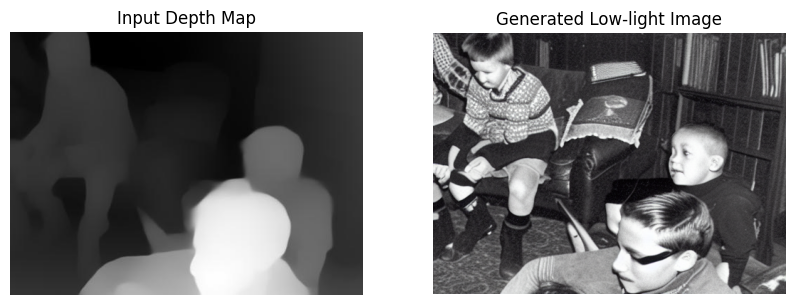

生成完毕！已自动保存为: /kaggle/working/test_gen_Bottle_2015_01332.jpg


In [26]:
import torch
import os
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
from PIL import Image
import matplotlib.pyplot as plt


# 1. 自定义测试配置

# ①模型路径
controlnet_path = "/kaggle/working/lowlight_controlnet_bicycle_full" 

# ②测试的深度图名称
# test_image_name = "Bicycle_2015_00002.png" 
# test_image_name = "Boat_2015_00675.jpg"
test_image_name = "Bottle_2015_01332.jpg"



# ③文本描述 (Prompt)
# Bicycle_2015_00001
# prompt = "A picture of a room with a bike and a bed"
# prompt = "extremely low light environment, underexposed, a bicycle in a dark room, shadows"

# Bicycle_2015_00002
# prompt = "A picture of a bike rack with a few bikes on it"
# prompt = "A picture of a bike rack with a few bikes on it，purely dark, night time, heavy shadows, low light environment"

# Boat_2015_00653
# prompt = "A picture of a sunset over the ocean with boats in the water"
# prompt = "extremely low light environment, underexposed, a bicycle in a dark room, shadows"

# Boat_2015_00654
#prompt = "A picture of boats decorated with lights on the water"

# Boat_2015_00675
# prompt = "A picture of a sailboat in the water with the chicago skyline in the background at night"

# Bottle_2015_01332
prompt = "A picture of the group of people sitting on the couch"

# ④负面提示词 (默认不要什么样的图片)
# negative_prompt = "bright, sunny, daytime, overexposed, ugly, blurry, high key, well lit"
negative_prompt = "bright, well lit, sunlight, daylight, colorful, vibrant, white light, indoor lighting, overexposed"



#  2. 加载模型与生成代码 
print(f"🚀 正在加载 ControlNet: {os.path.basename(controlnet_path)} ...")
device = "cuda"
base_model_id = "runwayml/stable-diffusion-v1-5"

# 加载模型
controlnet = ControlNetModel.from_pretrained(controlnet_path, torch_dtype=torch.float16).to(device)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    base_model_id, controlnet=controlnet, torch_dtype=torch.float16
).to(device)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()

# 组合完整路径
depth_dir = "/kaggle/input/datasets/yapeng111/depth-e-dataset"
test_depth_path = os.path.join(depth_dir, test_image_name)

if not os.path.exists(test_depth_path):
    print(f"找不到测试图片: {test_depth_path}")
    print("请检查：1. 名字是否拼写正确；2. 后缀是 .jpg 还是 .png。")
else:
    print(f"成功读取测试深度图: {test_image_name}")
    depth_image = Image.open(test_depth_path).convert("RGB")
    
    print(f"开始生成低光照图像 (20 steps)...\n📝 Prompt: {prompt}")
    
    # 取消固定种子，同样的图和文本，每次生成的细节也不同
    # 想要结果完全一样，把下面两行改回 generator = torch.manual_seed(42)
    generator = torch.manual_seed(42)
    # generator = torch.Generator(device="cpu").manual_seed(torch.randint(0, 1000000, (1,)).item())
    
    output_image = pipe(
        prompt,
        image=depth_image,
        negative_prompt=negative_prompt,
        num_inference_steps=20,
        guidance_scale=7.5,
        generator=generator
    ).images[0]

    # 可视化对比
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(depth_image)
    axes[0].set_title("Input Depth Map")
    axes[0].axis("off")
    
    axes[1].imshow(output_image)
    axes[1].set_title("Generated Low-light Image")
    axes[1].axis("off")
    plt.show()

    # 保存生成的图片到工作区 (自动用深度图的名字命名)
    save_name = f"/kaggle/working/test_gen_{test_image_name}"
    output_image.save(save_name)
    print(f"生成完毕！已自动保存为: {save_name}")

# 完整数据集，代码需要修改，不生成模型文件，有问题

In [6]:
# 完整数据集


import os
import torch
import cv2
import json
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers.models import AutoencoderKL, UNet2DConditionModel


# 1. 自定义数据集 (对齐 L0, D1, T1)
class LowLightControlNetDataset(Dataset):
    def __init__(self, exdark_dir, depth_dir, caption_json_path, tokenizer, size=512):
        self.tokenizer = tokenizer
        
        # 1. 加载 JSON，并创建一个大小写不敏感的“无后缀”映射字典
        # 这样即使 JSON 里写的是 .JPG，实际文件是 .jpg 也能完美匹配
        with open(caption_json_path, 'r', encoding='utf-8') as f:
            raw_captions = json.load(f)
        self.captions_dict = {os.path.splitext(k)[0].lower(): v for k, v in raw_captions.items()}

        # 2. 扫描 Depth 目录，建立 base_name 到实际路径的映射
        self.depth_dict = {}
        for root, _, files in os.walk(depth_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    base_name = os.path.splitext(f)[0].lower()
                    self.depth_dict[base_name] = os.path.join(root, f)

        # 3. 扫描 ExDark 目录，进行三元组严格对齐和过滤
        self.valid_data = []
        for root, _, files in os.walk(exdark_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, f)
                    parent_folder = os.path.basename(root) # 例如 "Car" 或 "Bicycle"

                    # 修复命名：如果原图少了类别前缀 (例如 2015_02861.jpg)，自动把它补全为 Car_2015_02861
                    if f.lower().startswith(parent_folder.lower()):
                        normalized_f = f
                    else:
                        normalized_f = f"{parent_folder}_{f}"
                        
                    base_name = os.path.splitext(normalized_f)[0].lower() # 例如 car_2015_02861

                    # 黄金法则：只有当深度图存在时，才把这条数据加入训练集！
                    if base_name in self.depth_dict:
                        self.valid_data.append({
                            "img_path": img_path,
                            "depth_path": self.depth_dict[base_name],
                            "base_key": base_name # 用于去 JSON 里找描述
                        })

        print(f"数据清洗对齐完毕！共成功匹配到 {len(self.valid_data)} 个完整的数据对。")
        if len(self.valid_data) == 0:
            raise ValueError("严重警告：没有找到任何匹配的原图和深度图，请检查三个根路径是否正确！")

        # 图像与深度图的预处理
        self.image_transforms = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        
        self.condition_transforms = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        item = self.valid_data[idx]
        
        # --- 加载 L0 (原低光图) ---
        image = Image.open(item["img_path"]).convert("RGB")
        image_tensor = self.image_transforms(image)
        
        # --- 加载 D1 (深度图) ---
        depth_map = Image.open(item["depth_path"]).convert("RGB")
        depth_tensor = self.condition_transforms(depth_map)
        
        # --- 加载 T1 (文本描述) ---
        text = self.captions_dict.get(item["base_key"], "A picture in the dark")
            
        # 文本分词
        inputs = self.tokenizer(
            text, 
            max_length=self.tokenizer.model_max_length, 
            padding="max_length", 
            truncation=True, 
            return_tensors="pt"
        )
        
        return {
            "pixel_values": image_tensor,     
            "conditioning_pixel_values": depth_tensor, 
            "input_ids": inputs.input_ids.squeeze()    
        }

# 2. 模型初始化与冻结设置
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "runwayml/stable-diffusion-v1-5" # 论文使用的基础模型

# 加载各个组件
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to(device)
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# 初始化 ControlNet
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth").to(device)

# 核心设定：冻结 VAE, U-Net 和 Text Encoder，仅训练 ControlNet
vae.requires_grad_(False)
unet.requires_grad_(False)
text_encoder.requires_grad_(False)
controlnet.train()

# 开启梯度检查点以节省显存
controlnet.enable_gradient_checkpointing()


# 3. 训练超参数与数据加载
batch_size = 2 # 如果提示 CUDA OOM，请将此数值改为 1
learning_rate = 1e-5
num_epochs = 10


EXDARK_DIR = "/kaggle/input/datasets/yapeng111/exdark-dataset" 
DEPTH_DIR = "/kaggle/input/datasets/yapeng111/depth-e-dataset"
CAPTION_DIR = "/kaggle/input/datasets/yapeng111/captions-e/captions_E.json"

dataset = LowLightControlNetDataset(EXDARK_DIR, DEPTH_DIR, CAPTION_DIR, tokenizer)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimizer = torch.optim.AdamW(controlnet.parameters(), lr=learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer, num_warmup_steps=500, num_training_steps=len(dataloader) * num_epochs
)

# 混合精度 Scaler
scaler = torch.cuda.amp.GradScaler()


# 4. 训练循环 (Stage 2: Training Model M1)
print("Starting training...")
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step, batch in enumerate(dataloader):
        # 1. 准备数据
        latents = vae.encode(batch["pixel_values"].to(device, dtype=torch.float32)).latent_dist.sample()
        latents = latents * vae.config.scaling_factor
        
        controlnet_image = batch["conditioning_pixel_values"].to(device, dtype=torch.float32)
        encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]
        
        # 2. 为 Latents 添加噪声 (Forward Diffusion)
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        with torch.cuda.amp.autocast():
            # 3. ControlNet 前向传播
            down_block_res_samples, mid_block_res_sample = controlnet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                controlnet_cond=controlnet_image,
                return_dict=False,
            )
            
            # 4. U-Net 预测噪声 (结合 ControlNet 的输出)
            model_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                down_block_additional_residuals=down_block_res_samples,
                mid_block_additional_residual=mid_block_res_sample,
            ).sample
            
            # 5. 计算 Loss (预测的噪声 vs 实际加入的噪声)
            loss = torch.nn.functional.mse_loss(model_pred.float(), noise.float(), reduction="mean")
        
        # 6. 反向传播与优化
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()
        
        epoch_loss += loss.item()
        
        if step % 50 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Step [{step}/{len(dataloader)}], Loss: {loss.item():.4f}")
            
    print(f"--- Epoch {epoch} Average Loss: {epoch_loss/len(dataloader):.4f} ---")


# 5. 保存训练好的 ControlNet 模型
output_dir = "/kaggle/working/lowlight_controlnet_v1"
controlnet.save_pretrained(output_dir)
print(f"Training complete! Model saved to {output_dir}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyboardInterrupt: 